In [27]:
# ==============================================================================
# TASK 5: EXECUTIVE BUSINESS ANALYTICS & STRATEGIC MARKET REPORT
# Author: Pradeep Singh
# Dataset: Zomato Bangalore (zomato.csv)
# Framework: Python, Pandas, NumPy, Matplotlib, Seaborn
# ==============================================================================

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [29]:
# ------------------------------------------------------------------------------
# 1. INGESTION & ROBUST DATA PIPELINE
# ------------------------------------------------------------------------------
df_raw = pd.read_csv("zomato.csv")

cols = [
    "name", "online_order", "book_table", "rate", "votes",
    "location", "rest_type", "cuisines", "approx_cost(for two people)", "listed_in(type)"
]
df = df_raw[cols].drop_duplicates().reset_index(drop=True)

In [30]:
# Parse Clean Numeric Rating
def parse_rating(val):
    if pd.isna(val) or val == "NEW" or val == "-":
        return np.nan
    try:
        return float(str(val).split("/")[0].strip())
    except:
        return np.nan

In [31]:
# Parse Clean Cost for Two
def parse_cost(val):
    if pd.isna(val):
        return np.nan
    try:
        return float(str(val).replace(",", "").strip())
    except:
        return np.nan

df["rating_clean"] = df["rate"].apply(parse_rating)
df["cost_clean"] = df["approx_cost(for two people)"].apply(parse_cost)

In [32]:
# Median Imputations
df["rating_clean"] = df["rating_clean"].fillna(df["rating_clean"].median())
df["cost_clean"] = df["cost_clean"].fillna(df["cost_clean"].median())

In [33]:
# String-level clean for boolean flags
df["online_order_clean"] = df["online_order"].astype(str).str.strip().str.lower()
df["book_table_clean"] = df["book_table"].astype(str).str.strip().str.lower()

df["is_online_order"] = df["online_order_clean"].apply(lambda x: 1 if x == "yes" else 0)
df["is_book_table"] = df["book_table_clean"].apply(lambda x: 1 if x == "yes" else 0)

In [34]:
# Drop sparse nulls
df = df.dropna(subset=["location", "rest_type", "cuisines", "listed_in(type)"]).reset_index(drop=True)

In [35]:
# Feature 1: Menu Complexity
df["cuisine_count"] = df["cuisines"].apply(lambda x: len(str(x).split(",")))
df["menu_complexity"] = df["cuisine_count"].apply(
    lambda x: "Focused (1-2)" if x <= 2 else ("Standard (3-4)" if x <= 4 else "Extensive (5+)")
)

In [36]:
# Feature 2: 4-Quadrant Operating Model
def assign_model(r):
    if r["is_online_order"] == 1 and r["is_book_table"] == 1:
        return "Hybrid Full-Service"
    elif r["is_online_order"] == 1 and r["is_book_table"] == 0:
        return "Delivery-First"
    elif r["is_online_order"] == 0 and r["is_book_table"] == 1:
        return "Premium Dine-in"
    else:
        return "Traditional Offline"

df["business_model"] = df.apply(assign_model, axis=1)

In [37]:
# Feature 3: Primary Format
df["primary_format"] = df["rest_type"].apply(lambda x: str(x).split(",")[0].strip())

print(f"Data Pipeline Verified. Total Outlets: {df.shape[0]}")
print("Verified Business Model Distribution:\n", df["business_model"].value_counts())

Data Pipeline Verified. Total Outlets: 34836
Verified Business Model Distribution:
 business_model
Delivery-First         17609
Traditional Offline    11825
Hybrid Full-Service     3112
Premium Dine-in         2290
Name: count, dtype: int64


In [38]:
# ------------------------------------------------------------------------------
# 2. DASHBOARD 1: MARKET STRUCTURE & GEOGRAPHY (4 Charts)
# ------------------------------------------------------------------------------

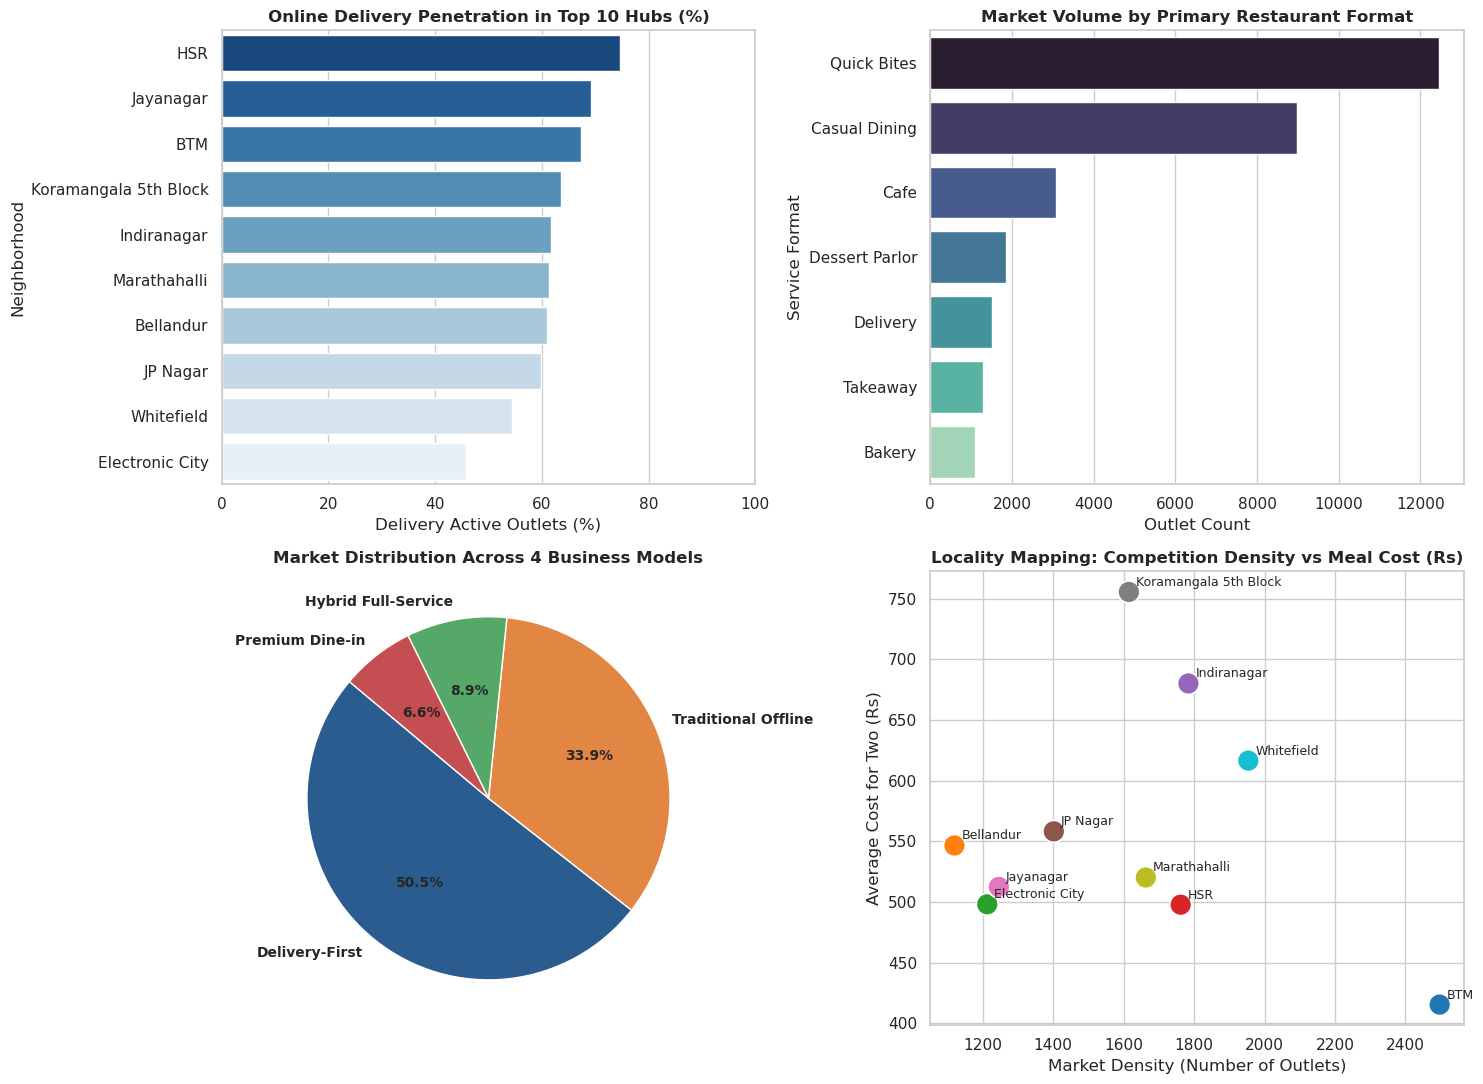

Dashboard 1 saved successfully.


In [39]:
fig1, axes1 = plt.subplots(2, 2, figsize=(15, 11))

# 1. Delivery Penetration % Across Top 10 Localities
top10_locations = df["location"].value_counts().head(10).index
loc_deliv = df[df["location"].isin(top10_locations)].groupby("location")["is_online_order"].mean().reset_index()
loc_deliv["delivery_rate"] = (loc_deliv["is_online_order"] * 100).round(1)
loc_deliv = loc_deliv.sort_values(by="delivery_rate", ascending=False)

sns.barplot(
    data=loc_deliv, 
    x="delivery_rate", 
    y="location", 
    hue="location", 
    legend=False, 
    ax=axes1[0, 0], 
    palette="Blues_r"
)
axes1[0, 0].set_title("Online Delivery Penetration in Top 10 Hubs (%)", fontsize=12, fontweight="bold")
axes1[0, 0].set_xlabel("Delivery Active Outlets (%)")
axes1[0, 0].set_ylabel("Neighborhood")
axes1[0, 0].set_xlim(0, 100)

# 2. Market Share by Restaurant Format
top_formats = df["primary_format"].value_counts().head(7).reset_index()
top_formats.columns = ["Format", "Count"]
sns.barplot(
    data=top_formats, 
    x="Count", 
    y="Format", 
    hue="Format", 
    legend=False, 
    ax=axes1[0, 1], 
    palette="mako"
)
axes1[0, 1].set_title("Market Volume by Primary Restaurant Format", fontsize=12, fontweight="bold")
axes1[0, 1].set_xlabel("Outlet Count")
axes1[0, 1].set_ylabel("Service Format")

# 3. 4-Quadrant Operating Model Market Split (Pie Chart)
model_counts = df["business_model"].value_counts()
axes1[1, 0].pie(
    model_counts, 
    labels=model_counts.index, 
    autopct="%1.1f%%",
    colors=["#2b5c8f", "#e28743", "#55a868", "#c44e52"], 
    startangle=140,
    textprops={"fontsize": 10, "weight": "bold"}
)
axes1[1, 0].set_title("Market Distribution Across 4 Business Models", fontsize=12, fontweight="bold")

# 4. Locality Spending Power vs Supply Density
loc_metrics = df[df["location"].isin(top10_locations)].groupby("location").agg(
    Density=("name", "count"),
    Avg_Cost=("cost_clean", "mean")
).reset_index()
sns.scatterplot(
    data=loc_metrics, 
    x="Density", 
    y="Avg_Cost", 
    hue="location", 
    s=250, 
    legend=False, 
    ax=axes1[1, 1], 
    palette="tab10"
)
for _, row in loc_metrics.iterrows():
    axes1[1, 1].text(row["Density"] + 20, row["Avg_Cost"] + 5, row["location"], fontsize=9)
axes1[1, 1].set_title("Locality Mapping: Competition Density vs Meal Cost (Rs)", fontsize=12, fontweight="bold")
axes1[1, 1].set_xlabel("Market Density (Number of Outlets)")
axes1[1, 1].set_ylabel("Average Cost for Two (Rs)")

plt.tight_layout()
plt.savefig("zomato_analytics_dashboard_part1.png", dpi=300)
plt.show()
print("Dashboard 1 saved successfully.")

In [40]:
# ------------------------------------------------------------------------------
# 3. DASHBOARD 2: UNIT ECONOMICS & OPERATIONAL EFFICIENCY (4 Charts)
# ------------------------------------------------------------------------------

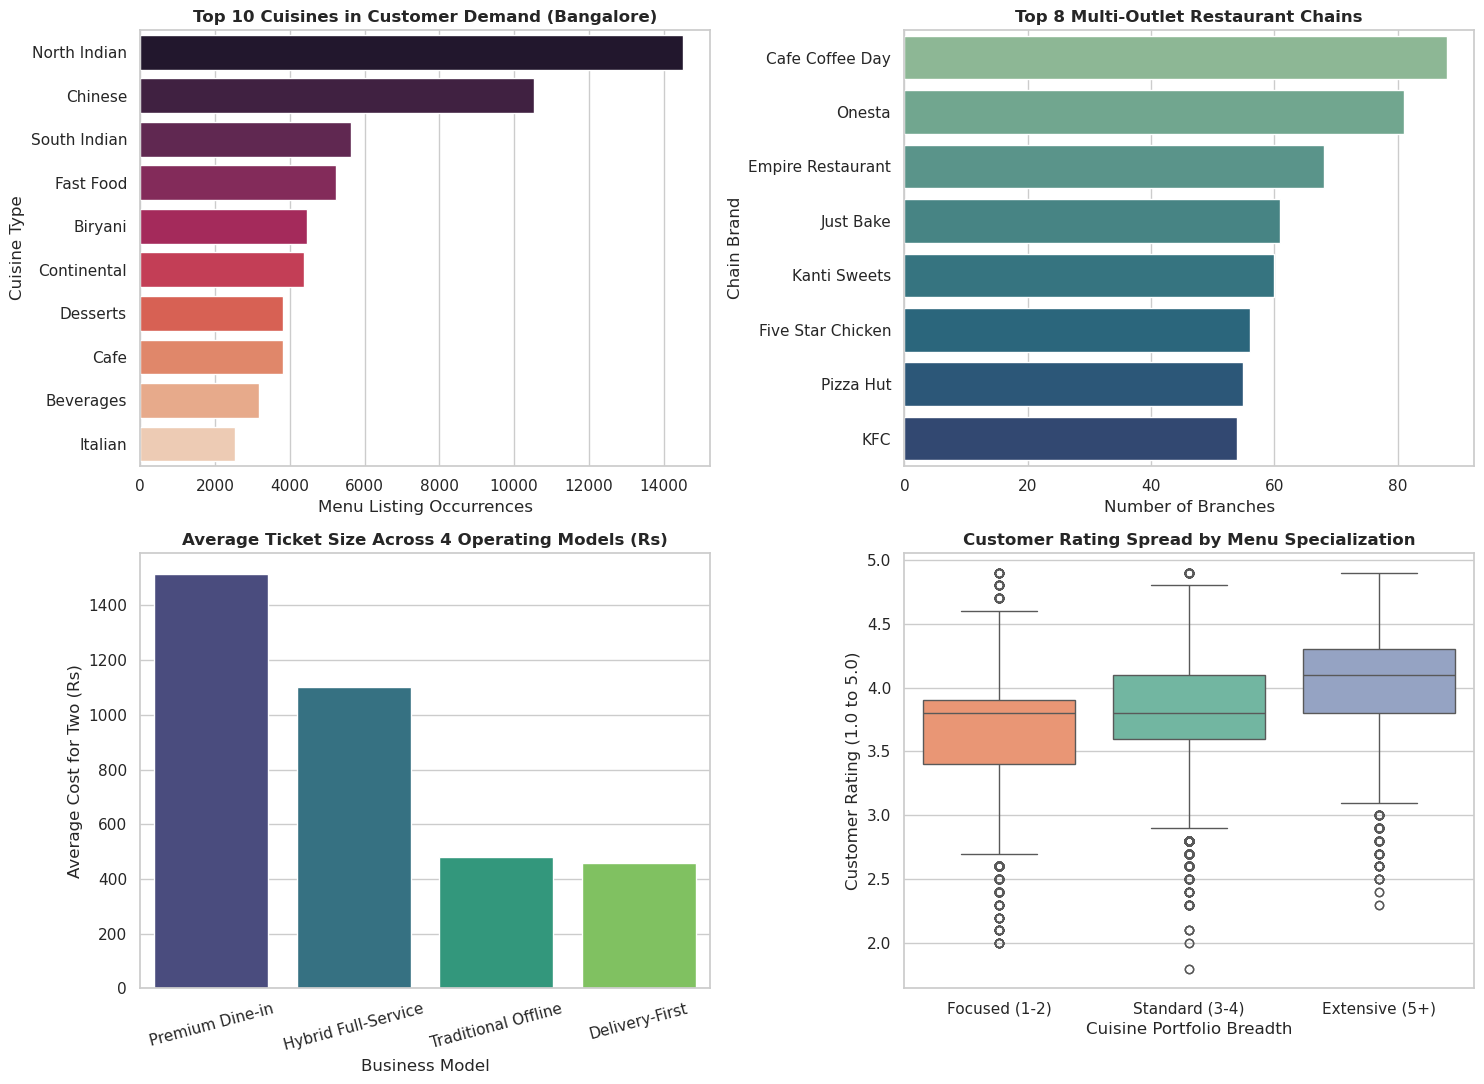

Dashboard 2 saved successfully.


In [41]:
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 11))

# 5. Top 10 Individual Cuisines
cuisine_items = []
for item in df["cuisines"].dropna():
    for c in str(item).split(","):
        cuisine_items.append(c.strip())
cuisine_df = pd.Series(cuisine_items).value_counts().head(10).reset_index()
cuisine_df.columns = ["Cuisine", "Mentions"]
sns.barplot(
    data=cuisine_df, 
    x="Mentions", 
    y="Cuisine", 
    hue="Cuisine", 
    legend=False, 
    ax=axes2[0, 0], 
    palette="rocket"
)
axes2[0, 0].set_title("Top 10 Cuisines in Customer Demand (Bangalore)", fontsize=12, fontweight="bold")
axes2[0, 0].set_xlabel("Menu Listing Occurrences")
axes2[0, 0].set_ylabel("Cuisine Type")

# 6. Top 8 Restaurant Brands by Physical Outlets
top_brands = df["name"].value_counts().head(8).reset_index()
top_brands.columns = ["Brand", "Outlets"]
sns.barplot(
    data=top_brands, 
    x="Outlets", 
    y="Brand", 
    hue="Brand", 
    legend=False, 
    ax=axes2[0, 1], 
    palette="crest"
)
axes2[0, 1].set_title("Top 8 Multi-Outlet Restaurant Chains", fontsize=12, fontweight="bold")
axes2[0, 1].set_xlabel("Number of Branches")
axes2[0, 1].set_ylabel("Chain Brand")

# 7. Average Cost for Two Across the 4 Business Models
model_ticket = df.groupby("business_model")["cost_clean"].mean().reset_index().sort_values(by="cost_clean", ascending=False)
sns.barplot(
    data=model_ticket, 
    x="business_model", 
    y="cost_clean", 
    hue="business_model", 
    legend=False, 
    ax=axes2[1, 0], 
    palette="viridis"
)
axes2[1, 0].set_title("Average Ticket Size Across 4 Operating Models (Rs)", fontsize=12, fontweight="bold")
axes2[1, 0].set_xlabel("Business Model")
axes2[1, 0].set_ylabel("Average Cost for Two (Rs)")
axes2[1, 0].tick_params(axis="x", rotation=15)

# 8. Menu Complexity vs Customer Rating Consistency
sns.boxplot(
    data=df, 
    x="menu_complexity", 
    y="rating_clean", 
    hue="menu_complexity", 
    legend=False, 
    ax=axes2[1, 1], 
    palette="Set2",
    order=["Focused (1-2)", "Standard (3-4)", "Extensive (5+)"]
)
axes2[1, 1].set_title("Customer Rating Spread by Menu Specialization", fontsize=12, fontweight="bold")
axes2[1, 1].set_xlabel("Cuisine Portfolio Breadth")
axes2[1, 1].set_ylabel("Customer Rating (1.0 to 5.0)")

plt.tight_layout()
plt.savefig("zomato_analytics_dashboard_part2.png", dpi=300)
plt.show()
print("Dashboard 2 saved successfully.")
